In [4]:
import sys
print(sys.executable)

c:\Users\dell\AppData\Local\Python\pythoncore-3.14-64\python.exe


In [5]:
!pip install pandas

In [1]:
pip install pandas numpy scikit-learn matplotlib xgboost jupyter


   ------------- -------------------------- 2/6 [lark]
   ------------- -------------------------- 2/6 [lark]
   -------------------- ------------------- 3/6 [fqdn]
   ---------------------------------------- 6/6 [isoduration]

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

from xgboost import XGBClassifier

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
df = pd.read_csv("wine_data.csv")

print(df.shape)
df.head()

(21000, 12)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,11.6,0.580,0.66,2.20,0.074,10.0,47.0,1.00080,3.25,0.57,9.0,3
1,10.4,0.610,0.49,2.10,0.200,5.0,16.0,0.99940,3.16,0.63,8.4,3
2,7.4,1.185,0.00,4.25,0.097,5.0,14.0,0.99660,3.63,0.54,10.7,3
3,10.4,0.440,0.42,1.50,0.145,34.0,48.0,0.99832,3.38,0.86,9.9,3
4,8.3,1.020,0.02,3.40,0.084,6.0,11.0,0.99892,3.48,0.49,11.0,3


In [4]:
X = df.drop("quality", axis=1)

y = (df["quality"] >= 6).astype(int)

print(X.shape)
print(y.shape)

(21000, 11)
(21000,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(16800, 11)
(4200, 11)


In [6]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Done")

Decision Tree Done


In [7]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Done")

Random Forest Done


In [8]:
xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

print("XGBoost Done")

XGBoost Done


In [9]:
from sklearn.metrics import f1_score

dt_f1 = f1_score(y_test, dt_pred)
rf_f1 = f1_score(y_test, rf_pred)
xgb_f1 = f1_score(y_test, xgb_pred)

print("Decision Tree F1 Score:", dt_f1)
print("Random Forest F1 Score:", rf_f1)
print("XGBoost F1 Score:", xgb_f1)

Decision Tree F1 Score: 0.7755187591699854
Random Forest F1 Score: 0.8082137161084529
XGBoost F1 Score: 0.7755102040816326


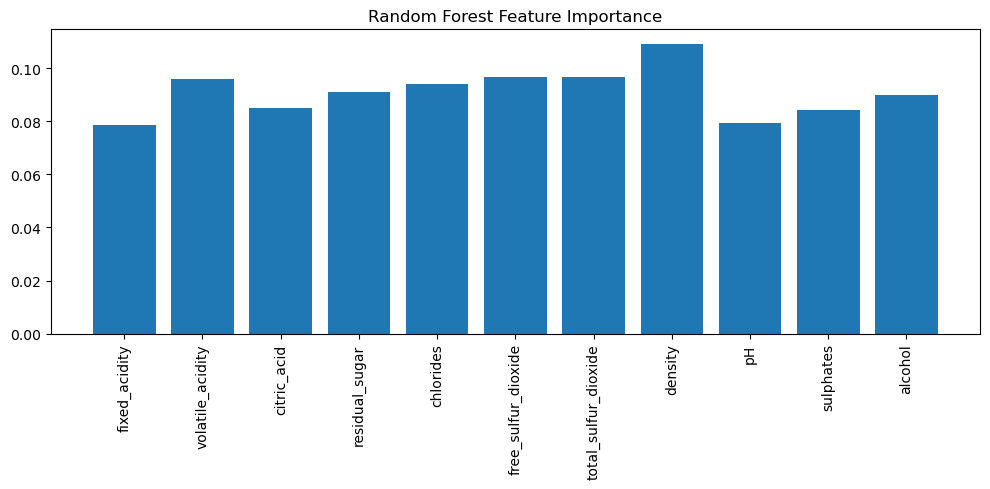

In [10]:
import matplotlib.pyplot as plt

importance = rf.feature_importances_
features = X.columns

plt.figure(figsize=(10,5))
plt.bar(features, importance)
plt.xticks(rotation=90)
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

In [11]:
from sklearn.inspection import permutation_importance
import pandas as pd

result = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

perm_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': result.importances_mean
})

print(perm_importance.sort_values(by='Importance', ascending=False))

                 Feature  Importance
1       volatile_acidity    0.063762
10               alcohol    0.049214
7                density    0.028571
3         residual_sugar    0.025833
6   total_sulfur_dioxide    0.023524
4              chlorides    0.022357
9              sulphates    0.019690
5    free_sulfur_dioxide    0.017452
2            citric_acid    0.003476
8                     pH    0.002881
0          fixed_acidity    0.001833
